In [ ]:
!pip install -q unsloth rouge-score bert-score evaluate matplotlib seaborn
# unsloth already pulls in transformers, peft, trl, bitsandbytes

In [ ]:
!pip install transformers==4.44.2 trl==0.9.6

In [ ]:
!rm -rf /kaggle/working/unsloth_compiled_cache

In [ ]:
!pip install --upgrade --no-cache-dir transformers trl unsloth unsloth_zoo accelerate peft
!rm -rf /kaggle/working/unsloth_compiled_cache

In [ ]:
!pip uninstall -y unsloth

In [ ]:
!pip install "unsloth @ git+https://github.com/unslothai/unsloth.git"

In [ ]:
!rm -rf /kaggle/working/unsloth_compiled_cache

In [1]:
import torch, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.auto import tqdm
import evaluate
from bert_score import score as bert_score_fn

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# ── CONFIG (same as your training script) ──────────────────────────────────
MODEL_NAME      = "unsloth/Phi-3-mini-4k-instruct-bnb-4bit"
DATA_PATH       = "/kaggle/input/datasets/omarabdelhamedomar/cleaned-dataset/cleaned_resume_finetune_data.jsonl"
ADAPTER_DIR     = "lora_adapter"   # where we save after training
MAX_SEQ_LENGTH  = 2048
N_EVAL_SAMPLES  = 50               # held-out samples (taken from end of dataset)
MAX_NEW_TOKENS  = 256
# ───────────────────────────────────────────────────────────────────────────

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

2026-05-10 08:37:21.970309: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778402242.345196     251 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778402242.491653     251 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778402243.451018     251 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778402243.451057     251 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778402243.451060     251 computation_placer.cc:177] computation placer alr

Device: cuda


In [2]:
from datasets import load_dataset
from unsloth.chat_templates import get_chat_template

full_ds = load_dataset('json', data_files=DATA_PATH, split='train')
total   = len(full_ds)

# Keep last N samples for evaluation — never seen during training
train_ds = full_ds.select(range(total - N_EVAL_SAMPLES))
test_ds  = full_ds.select(range(total - N_EVAL_SAMPLES, total))

print(f"Total: {total}  |  Train: {len(train_ds)}  |  Eval: {len(test_ds)}")
print("Keys:", list(test_ds[0].keys()))

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


Generating train split: 0 examples [00:00, ? examples/s]

Total: 1223  |  Train: 1173  |  Eval: 50
Keys: ['messages']


In [3]:
def split_messages(sample):
    """Returns (prompt_messages, reference_string) from a messages sample."""
    msgs = sample["messages"]
    last_asst = max(i for i, m in enumerate(msgs) if m["role"] == "assistant")
    return msgs[:last_asst], msgs[last_asst]["content"]


def generate(model, tokenizer, prompt_messages):
    """Generate a response and return (text, latency_seconds)."""
    prompt_str = tokenizer.apply_chat_template(
        prompt_messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(
        prompt_str, return_tensors="pt",
        truncation=True, max_length=MAX_SEQ_LENGTH
    ).to(DEVICE)

    t0 = time.perf_counter()
    with torch.no_grad():
        out_ids = model.generate(
            **inputs,
            max_new_tokens = MAX_NEW_TOKENS,
            do_sample      = False,
            use_cache      = True,
            pad_token_id   = tokenizer.eos_token_id,
        )
    latency  = time.perf_counter() - t0
    new_ids  = out_ids[0][inputs["input_ids"].shape[1]:]
    response = tokenizer.decode(new_ids, skip_special_tokens=True).strip()
    return response, latency


def get_perplexity(model, tokenizer, text):
    enc = tokenizer(
        text, return_tensors="pt", truncation=True, max_length=512
    ).to(DEVICE)
    with torch.no_grad():
        loss = model(**enc, labels=enc["input_ids"]).loss
    return torch.exp(loss).item()


def token_f1(pred, ref):
    p = pred.lower().split(); r = ref.lower().split()
    common = sum((Counter(p) & Counter(r)).values())
    if not common: return 0.0
    return 2 * (common/len(p)) * (common/len(r)) / (common/len(p) + common/len(r))


def run_eval(model, tokenizer, label="model"):
    """Run full evaluation on test_ds. Returns a DataFrame."""
    rouge_metric = evaluate.load("rouge")
    records = []
    for i, sample in enumerate(tqdm(test_ds, desc=f"Evaluating {label}")):
        prompt_msgs, reference = split_messages(sample)
        pred, latency = generate(model, tokenizer, prompt_msgs)
        r = rouge_metric.compute(predictions=[pred], references=[reference])
        records.append({
            "sample_id"  : i,
            "reference"  : reference[:150],
            "prediction" : pred[:150],
            "rouge1"     : r["rouge1"],
            "rouge2"     : r["rouge2"],
            "rougeL"     : r["rougeL"],
            "token_f1"   : token_f1(pred, reference),
            "em"         : float(pred.strip().lower() == reference.strip().lower()),
            "perplexity" : get_perplexity(model, tokenizer, reference),
            "resp_len"   : len(pred.split()),
            "latency_s"  : latency,
        })

    df = pd.DataFrame(records)

    # BERTScore (batched)
    refs  = [split_messages(s)[1] for s in test_ds]
    preds = df["prediction"].tolist()
    _, _, bf1 = bert_score_fn(preds, refs, lang="en", verbose=False)
    df["bertscore"] = bf1.numpy()
    return df


print("Helpers defined ✓")

Helpers defined ✓


In [4]:
from unsloth import FastLanguageModel

print("Loading base model...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype          = None,
    load_in_4bit   = True,
)
tokenizer = get_chat_template(tokenizer, chat_template="phi-3",
    mapping={"role":"role","content":"content","user":"user","assistant":"assistant"})

# 1. Switch Unsloth to highly optimized inference mode
FastLanguageModel.for_inference(model)

# 2. Explicitly force Transformers to turn off gradient checkpointing for the forward pass
if hasattr(model, "gradient_checkpointing_disable"):
    model.gradient_checkpointing_disable()

print("Base model ready ✓  — running evaluation...")
base_df = run_eval(model, tokenizer, label="BASE")
print(f"\nBase eval done. Mean ROUGE-1: {base_df.rouge1.mean():.4f}")

Loading base model...
==((====))==  Unsloth 2026.5.2: Fast Mistral patching. Transformers: 4.57.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.26G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/194 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Base eval done. Mean ROUGE-1: 0.4939


In [ ]:
!rm -rf /kaggle/working/unsloth_compiled_cache

In [5]:
from trl import SFTTrainer
from transformers import TrainingArguments

# Attach LoRA adapters — same config as your training script
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj","k_proj","v_proj","o_proj",
                    "gate_proj","up_proj","down_proj"],
    lora_alpha=32,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

# Format training data — same as your script
def formatting_prompts_func(examples):
    convos = examples["messages"]
    texts = [tokenizer.apply_chat_template(c, tokenize=False,
                add_generation_prompt=False) for c in convos]
    return {"text": texts}

train_formatted = train_ds.map(formatting_prompts_func, batched=True)

trainer = SFTTrainer(
    model              = model,
    tokenizer          = tokenizer,
    train_dataset      = train_formatted,
    dataset_text_field = "text",
    max_seq_length     = 2048, 
    dataset_num_proc   = 2,
    args=TrainingArguments(
        per_device_train_batch_size = 1, 
        gradient_accumulation_steps = 8, 
        warmup_steps                = 10,
        num_train_epochs            = 3,
        learning_rate               = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps               = 10,
        optim                       = "adamw_8bit",
        weight_decay                = 0.01,
        lr_scheduler_type           = "linear",
        seed                        = 3407,
        output_dir                  = "outputs",
        save_strategy               = "no",
        dataloader_pin_memory       = False,
        report_to                   = "none",
        
        # --- THIS IS THE LINE THAT FIXES THE .MEAN() ERROR ---
        average_tokens_across_devices = False, 
    ),
)

print("Starting training...")
trainer.train()

# Save LoRA adapter
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"Training done ✓  Adapter saved to '{ADAPTER_DIR}'")

Unsloth 2026.5.2 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


Map:   0%|          | 0/1173 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/1173 [00:00<?, ? examples/s]

Starting training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,173 | Num Epochs = 3 | Total steps = 222
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 29,884,416 of 3,850,963,968 (0.78% trained)


Step,Training Loss
10,1.225400
20,0.793500
30,0.613900
40,0.514700
50,0.421000
60,0.408900
70,0.478600
80,0.455400
90,0.351100
100,0.399300


Training done ✓  Adapter saved to 'lora_adapter'


In [6]:
from unsloth import FastLanguageModel

# Switch to inference mode — same model object, now with trained LoRA weights
FastLanguageModel.for_inference(model)

print("Running fine-tuned evaluation...")
ft_df = run_eval(model, tokenizer, label="FINE-TUNED")
print(f"Fine-tuned eval done. Mean ROUGE-1: {ft_df.rouge1.mean():.4f}")

Running fine-tuned evaluation...


Evaluating FINE-TUNED:   0%|          | 0/50 [00:00<?, ?it/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Fine-tuned eval done. Mean ROUGE-1: 0.9095


In [7]:
metrics = [
    ("rouge1",     "ROUGE-1      ↑"),
    ("rouge2",     "ROUGE-2      ↑"),
    ("rougeL",     "ROUGE-L      ↑"),
    ("token_f1",   "Token F1     ↑"),
    ("em",         "Exact Match  ↑"),
    ("bertscore",  "BERTScore F1 ↑"),
    ("perplexity", "Perplexity   ↓"),
    ("resp_len",   "Avg Resp Len"),
    ("latency_s",  "Avg Latency (s)"),
]

rows = []
for col, label in metrics:
    b = base_df[col].mean()
    f = ft_df[col].mean()
    d = f - b
    rows.append({"Metric": label, "Base": round(b,4),
                 "Fine-tuned": round(f,4), "Δ": round(d,4),
                 "Δ%": f"{d/b*100:+.1f}%" if b else "—"})

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

         Metric    Base  Fine-tuned       Δ      Δ%
 ROUGE-1      ↑  0.4939      0.9095  0.4156  +84.2%
 ROUGE-2      ↑  0.3558      0.9071  0.5513 +154.9%
 ROUGE-L      ↑  0.4433      0.9091  0.4657 +105.1%
 Token F1     ↑  0.2770      0.9002  0.6232 +225.0%
 Exact Match  ↑  0.0000      0.3600  0.3600       —
 BERTScore F1 ↑  0.8436      0.8923  0.0487   +5.8%
 Perplexity   ↓  5.4518      2.4532 -2.9986  -55.0%
   Avg Resp Len 65.1800     94.3000 29.1200  +44.7%
Avg Latency (s) 10.7358     14.5993  3.8635  +36.0%


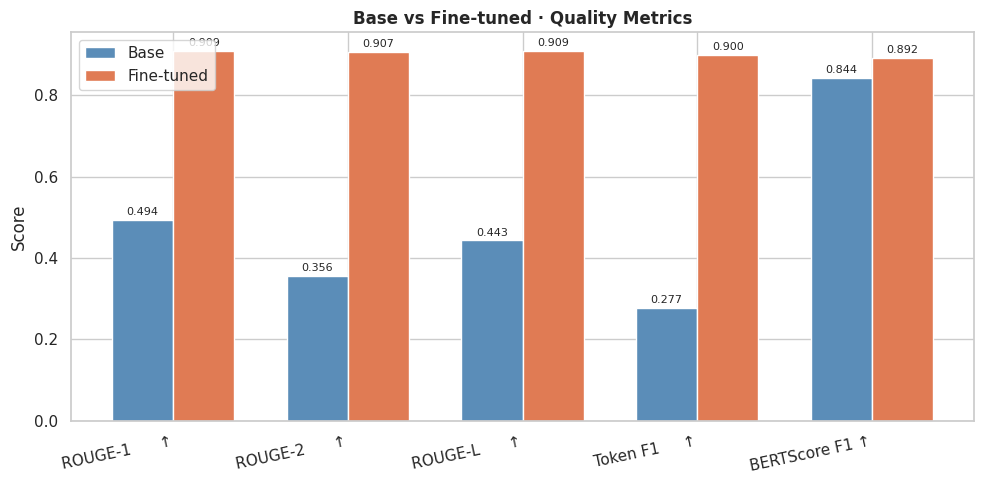

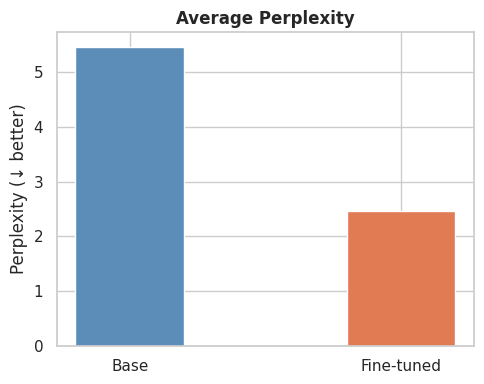

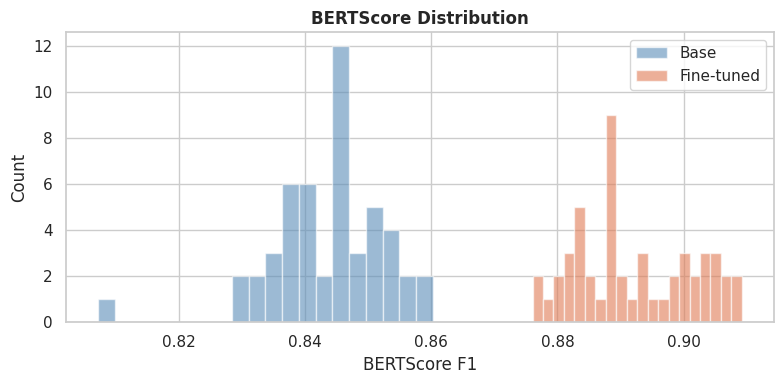

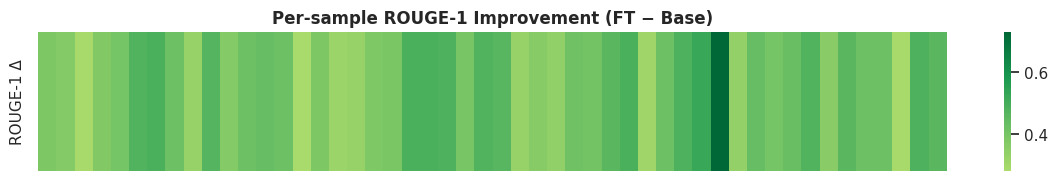

In [8]:
bar_labels = ["ROUGE-1      ↑","ROUGE-2      ↑","ROUGE-L      ↑",
              "Token F1     ↑","BERTScore F1 ↑"]
bar_df = summary[summary["Metric"].isin(bar_labels)]
x, w = np.arange(len(bar_df)), 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, bar_df["Base"],       w, label="Base",       color="#5B8DB8")
b2 = ax.bar(x + w/2, bar_df["Fine-tuned"], w, label="Fine-tuned", color="#E07B54")
ax.set_xticks(x); ax.set_xticklabels(bar_df["Metric"], rotation=12, ha="right")
ax.set_ylabel("Score"); ax.set_title("Base vs Fine-tuned · Quality Metrics", fontweight="bold")
ax.legend(); ax.bar_label(b1, fmt="%.3f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.3f", padding=2, fontsize=8)
plt.tight_layout(); plt.savefig("/content/metrics_bar.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Base", "Fine-tuned"],
       [base_df.perplexity.mean(), ft_df.perplexity.mean()],
       color=["#5B8DB8","#E07B54"], width=0.4)
ax.set_ylabel("Perplexity (↓ better)")
ax.set_title("Average Perplexity", fontweight="bold")
plt.tight_layout(); plt.savefig("/content/perplexity.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(base_df.bertscore, bins=20, alpha=0.6, label="Base",       color="#5B8DB8")
ax.hist(ft_df.bertscore,   bins=20, alpha=0.6, label="Fine-tuned", color="#E07B54")
ax.set_xlabel("BERTScore F1"); ax.set_ylabel("Count")
ax.set_title("BERTScore Distribution", fontweight="bold"); ax.legend()
plt.tight_layout(); plt.savefig("/content/bertscore_dist.png", dpi=150); plt.show()

delta = (ft_df.rouge1.values - base_df.rouge1.values)
fig, ax = plt.subplots(figsize=(12, 2))
sns.heatmap(delta.reshape(1,-1), cmap="RdYlGn", center=0, ax=ax,
            xticklabels=False, yticklabels=["ROUGE-1 Δ"])
ax.set_title("Per-sample ROUGE-1 Improvement (FT − Base)", fontweight="bold")
plt.tight_layout(); plt.savefig("/content/rouge1_heatmap.png", dpi=150); plt.show()

In [9]:
print(f"{'Metric':<20} {'FT Wins':>10} {'Ties':>8} {'Base Wins':>12}")
print("-" * 52)
for col, label in [("rouge1","ROUGE-1"),("rouge2","ROUGE-2"),("rougeL","ROUGE-L"),
                   ("token_f1","Token F1"),("bertscore","BERTScore")]:
    wins = (ft_df[col] > base_df[col]).mean()
    ties = (ft_df[col] == base_df[col]).mean()
    print(f"{label:<20} {wins:>9.1%} {ties:>7.1%} {1-wins-ties:>11.1%}")

print()
rouge1_delta = ft_df.rouge1.values - base_df.rouge1.values
for i in np.argsort(rouge1_delta)[-3:][::-1]:  # top 3 most improved
    print("═" * 70)
    print(f"Sample {i}  ROUGE-1 Δ={rouge1_delta[i]:+.3f}  "
          f"BERTScore Δ={ft_df.bertscore.iloc[i]-base_df.bertscore.iloc[i]:+.3f}")
    print(f"✅ REF : {base_df.reference.iloc[i][:200]}")
    print(f"🔵 BASE: {base_df.prediction.iloc[i][:200]}")
    print(f"🟠 FT  : {ft_df.prediction.iloc[i][:200]}")

Metric                  FT Wins     Ties    Base Wins
----------------------------------------------------
ROUGE-1                 100.0%    0.0%        0.0%
ROUGE-2                 100.0%    0.0%        0.0%
ROUGE-L                 100.0%    0.0%        0.0%
Token F1                100.0%    0.0%        0.0%
BERTScore               100.0%    0.0%        0.0%

══════════════════════════════════════════════════════════════════════
Sample 37  ROUGE-1 Δ=+0.731  BERTScore Δ=+0.075
✅ REF : {"candidate_name": "Jasmin Johnson", "contact_info": {"email": "jasmin.johnson@gmail.com", "phone": "+1-287-580-7279", "location": "Rodriguezchester, 
🔵 BASE: ```json

{

  "name": "Jasmin Johnson",

  "email": "jasmin.johnson@gmail.0000000000000000000000000000000000000000000000000000000000000000000000000000
🟠 FT  : {"candidate_name": "Jasmin Johnson", "contact_info": {"email": "jasmin.johnson@gmail.com", "phone": "+1-287-580-7279", "location": "Rodriguezchester, 
═════════════════════════════════════════